# 03 · Exploratory analysis — PTB Diagnostic ECG

14,552 heartbeats from the PTB Diagnostic database, in two classes: recordings from
healthy controls (`normal`) and from patients diagnosed with myocardial infarction
(`abnormal`). Same 187-sample format, same 125 Hz, same min-max normalisation as
MIT-BIH — which is what makes the transfer-learning setup of the source paper
possible.

This notebook runs the same battery of checks as notebook 02 and then compares the
two collections directly.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Works from a fresh clone (no `pip install -e .` needed) and on Databricks,
# where the repo folder is added to the workspace instead of installed.
try:
    import ecg
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import ecg

print("ecg", ecg.__version__)

ecg 0.1.0


In [2]:
import pandas as pd
from pyspark.sql import functions as F

from ecg import get_spark, load_config
from ecg import eda, viz
from ecg.features import add_beat_features
from ecg.ingest import load_beats

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

cfg = load_config()
spark = get_spark(cfg)
spark.sparkContext.setLogLevel("ERROR")
viz.apply_style()

SOURCE = "ptbdb"
ORDER = eda.ordered_labels(SOURCE)

beats = add_beat_features(load_beats(spark, cfg, source=SOURCE)).cache()
print(f"{beats.count():,} beats")
eda.dataset_overview(beats)

14,552 beats


,source,split,n_beats,n_classes,pct_of_total
0,ptbdb,full,14552,2,100.0


## 1 · Class balance

,label,label_name,n_beats,pct,description
0,0,normal,4046,27.804,Healthy control recording
1,1,abnormal,10506,72.196,Recording from a patient diagnosed with myocar...


,source,n_beats,n_classes,majority_class,majority_pct,minority_class,minority_pct,imbalance_ratio
0,ptbdb,14552,2,abnormal,72.2,normal,27.8,2.6


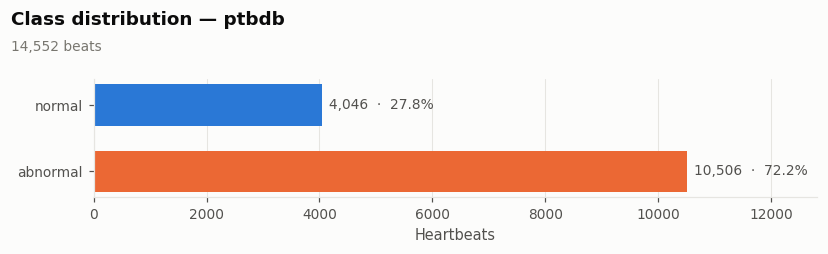

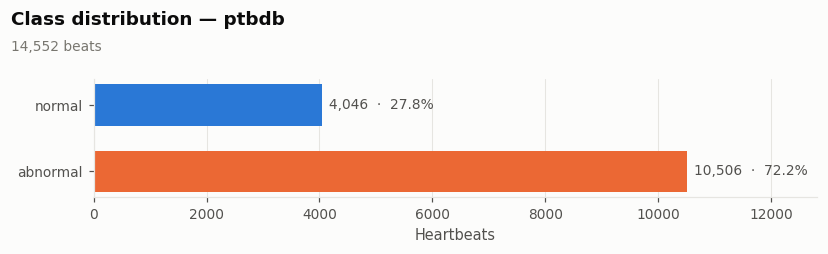

In [3]:
distribution = eda.class_distribution(beats)
display(distribution[["label", "label_name", "n_beats", "pct", "description"]])
display(eda.imbalance_summary(distribution))
viz.plot_class_distribution(distribution, SOURCE, ORDER)

**Finding.** The imbalance is mild — 72.2% abnormal against 27.8% normal, a 2.6:1
ratio — and it runs the *opposite* way to intuition: the pathological class is the
majority one, because the PTB database was assembled around myocardial infarction
cases. A 72% accuracy baseline is still trivially reachable, so balanced accuracy
and per-class recall remain the metrics to watch, but this collection needs far
less rebalancing than MIT-BIH.

Note also that the published files carry **no train/test split** — the split has to
be created, stratified and reproducibly, which notebook 04 does.

## 2 · Data quality

In [4]:
display(eda.quality_report(beats))
display(eda.duplicate_report(beats, by=("source",)))

,check,n_beats,pct
0,rows_total,14552,100.0
1,null_signal,0,0.0
2,wrong_length,0,0.0
3,null_label,0,0.0
4,contains_null_sample,0,0.0
5,contains_nan_sample,0,0.0
6,below_zero,0,0.0
7,above_one,0,0.0
8,all_zero_beat,0,0.0
9,max_not_one,0,0.0


,source,n_beats,n_unique_waveforms,n_duplicated_beats,n_waveforms_with_conflicting_labels,n_waveforms_in_both_splits,pct_duplicated
0,ptbdb,14552,14545,7,0,0,0.048


**Finding.** Cleaner than MIT-BIH on the normalisation front: every beat peaks at
exactly 1.0 and touches 0.0, with no clipped peaks at all. There are **7 duplicated
waveforms (0.05%)**, none of them carrying conflicting labels. Duplicates matter
here in a way they did not in MIT-BIH: with a split that has yet to be created, the
same waveform could land on both sides of it. Deduplicating before splitting — or
at minimum splitting on the waveform fingerprint — is the safe move.

## 3 · Morphology

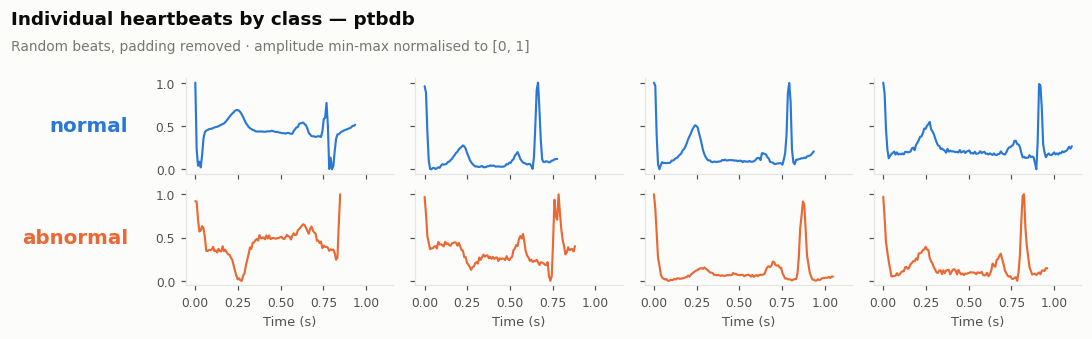

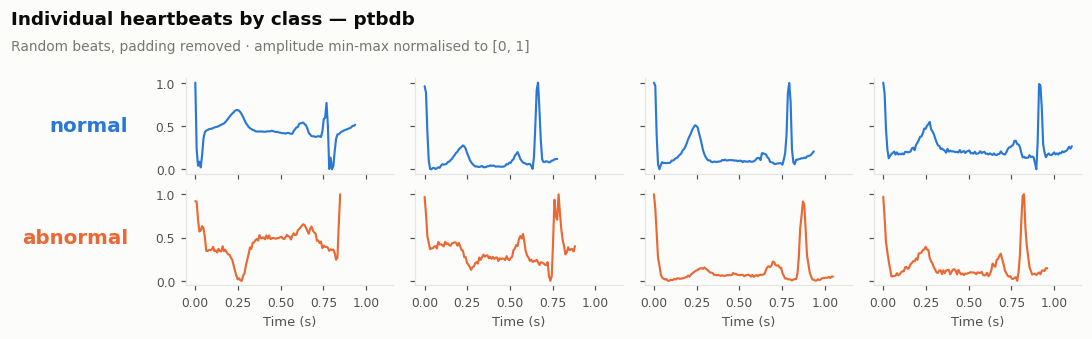

In [5]:
samples = eda.sample_beats(beats, n_per_group=cfg.plot_sample_per_class, seed=cfg.seed)
viz.plot_sample_beats(samples, SOURCE, ORDER, n_per_class=4)

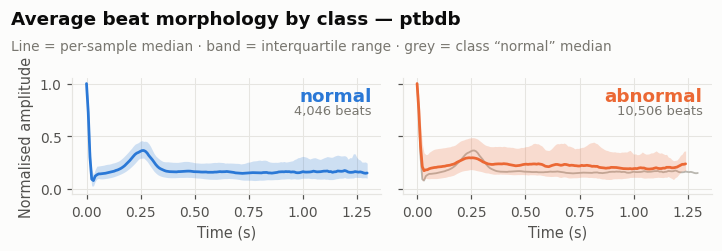

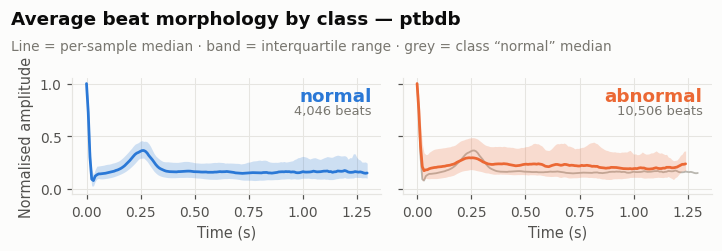

In [6]:
profile = eda.waveform_profile(beats)
viz.plot_waveform_profiles(profile, SOURCE, ORDER, n_cols=2)

**Finding.** The two median profiles differ less dramatically than the MIT-BIH
classes do, and in a clinically recognisable way: the abnormal profile sits higher
through the ST segment and its T wave is broader and later. This is the elevated ST
segment that defines an infarction on an ECG. The interquartile bands overlap
substantially, though — the separation is real but far from trivially linear.

## 4 · Padding and beat length

,source,label_name,n_beats,min_length,median_length,max_length,mean_length,mean_duration_s,pct_unpadded,pct_ambiguous_tail
0,ptbdb,abnormal,10506,51,110,186,112.6,0.9012,0.0,1.44
1,ptbdb,normal,4046,62,130,186,130.4,1.0435,0.0,0.15


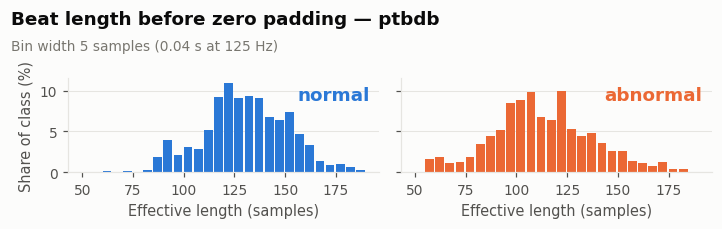

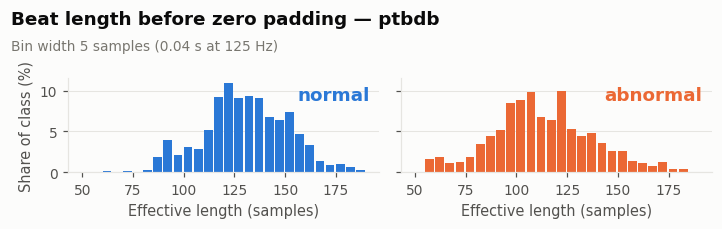

In [7]:
display(eda.padding_report(beats))
histogram = eda.length_histogram(beats)
viz.plot_length_distribution(histogram, SOURCE, ORDER, n_cols=2)

**Finding.** Normal beats are **18 samples longer on average** than abnormal ones
(130.4 vs 112.6 samples, 1.04 s vs 0.90 s). Since each segment spans one cardiac cycle,
that is a heart-rate difference: the infarction patients in this database are
simply tachycardic relative to the controls. It is a genuine signal — and a
cautionary one, because a classifier could reach a respectable score by measuring
heart rate alone rather than reading the ST segment. Worth checking against
`signal_length` when a model is eventually evaluated.

## 5 · Descriptors

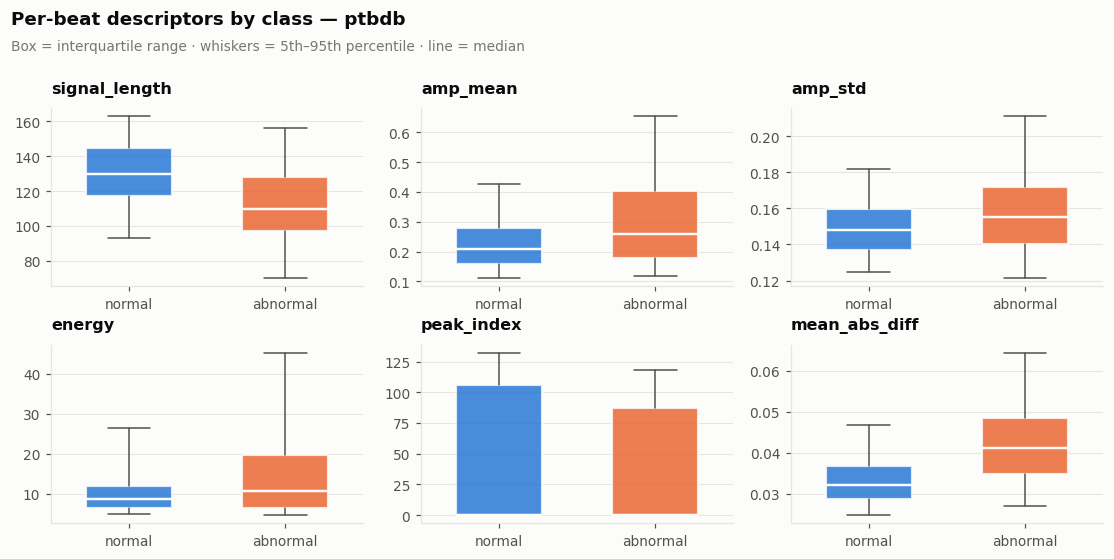

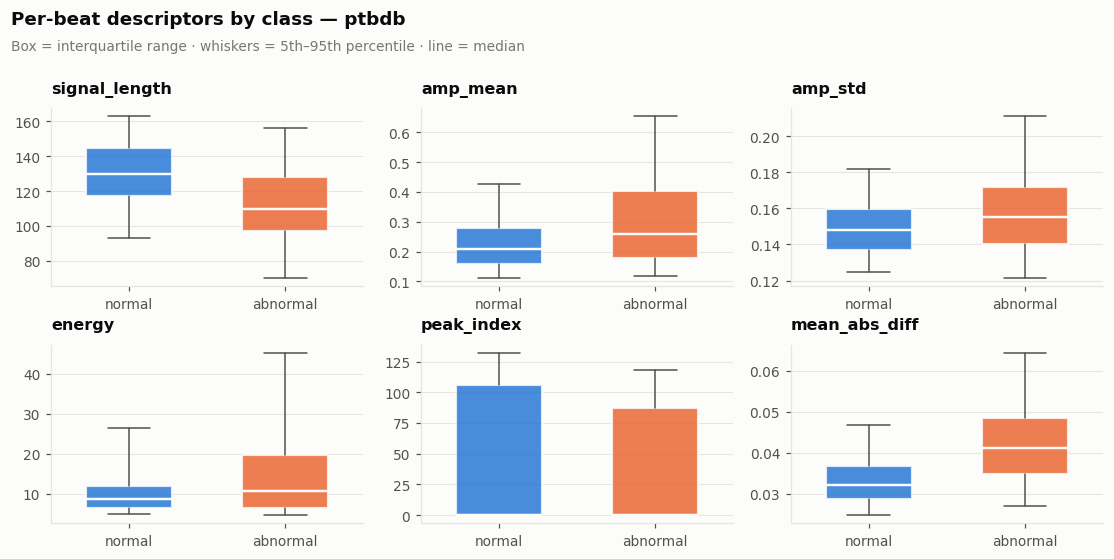

In [8]:
summary = eda.feature_summary(beats)
viz.plot_feature_boxes(
    summary,
    SOURCE,
    ["signal_length", "amp_mean", "amp_std", "energy", "peak_index", "mean_abs_diff"],
    ORDER,
)

In [9]:
correlation = eda.feature_correlation(beats)
correlation["label"].sort_values(key=abs, ascending=False).head(8).to_frame("r_with_label")

,r_with_label
label,1.000
mean_abs_diff,0.351
signal_length,-0.319
n_zeros,0.319
padding_ratio,0.319
duration_s,-0.319
rms,0.252
amp_mean,0.231


## 6 · The two collections side by side

In [10]:
both = add_beat_features(load_beats(spark, cfg))
comparison = (
    both.groupBy("source")
    .agg(
        F.count(F.lit(1)).alias("n_beats"),
        F.countDistinct("label").alias("n_classes"),
        F.round(F.avg("signal_length"), 1).alias("mean_length"),
        F.round(F.avg("duration_s"), 3).alias("mean_duration_s"),
        F.round(F.avg("amp_mean"), 4).alias("mean_amplitude"),
        F.round(F.avg("mean_abs_diff"), 5).alias("mean_abs_diff"),
    )
    .orderBy("source")
    .toPandas()
)
comparison

,source,n_beats,n_classes,mean_length,mean_duration_s,mean_amplitude,mean_abs_diff
0,mitbih,109446,5,111.6,0.893,0.2906,0.03801
1,ptbdb,14552,2,117.6,0.941,0.2871,0.04035


**Finding.** The two collections share format, sampling rate and normalisation, and
their aggregate statistics land close together — mean beat length within 6 samples
(111.6 vs 117.6), mean amplitude within 0.004 (0.291 vs 0.287). That similarity is
the practical justification for the
transfer-learning experiment in the source paper: a representation learned on the
109k MIT-BIH beats starts from a compatible input distribution when it is moved to
the 14.5k PTB beats.

| | MIT-BIH | PTB |
|---|---|---|
| Beats | 109,446 | 14,552 |
| Classes | 5 (N, S, V, F, Q) | 2 (normal, abnormal) |
| Imbalance ratio | 113:1 | 2.6:1 |
| Published split | train / test, stratified | none — must be created |
| Exact duplicates | 0 | 7 (0.05%) |
| Normalisation anomalies | 225 clipped peaks | none |

In [11]:
beats.unpersist()
spark.stop()